In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pysal.lib import weights # Untuk membuat matriks bobot spasial
from pysal.explore import esda # Untuk Moran's I
from splot.esda import plot_moran, plot_local_autocorrelation
from splot import esda as splot_esda
import mapclassify # Untuk skema klasifikasi peta choropleth

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\spaghetti\network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


In [2]:
df = pd.read_csv("C:/Uner/Lomba/Nacoesta/data_spasial.csv")
df

,Entity,Year,Exports of goods and services (constant 2015 US$),"Foreign direct investment, net outflows (% of GDP)","GDP per capita, PPP (constant 2021 international $)",Trade (% of GDP)
0,Albania,2022,5369630266,1.007042,17352.8540,84.698070
1,Algeria,2022,35079226621,0.037488,14782.2000,51.202377
2,Angola,2022,18269753380,0.039336,7397.4863,69.691070
3,Argentina,2022,71194353193,0.330257,27627.9630,31.547709
4,Armenia,2022,6973017223,0.254926,17886.1780,101.410780
...,...,...,...,...,...,...
133,United States of America,2022,2442520526660,1.493873,72841.9200,26.891690
134,Uruguay,2022,14853352487,8.409266,30879.9300,58.833620
135,Uzbekistan,2022,20452517364,0.004515,9607.5620,63.869255
136,Vanuatu,2022,149559148,0.145749,3122.6401,70.764180


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 6 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               138 non-null    object 
 1   Year                                                 138 non-null    int64  
 2   Exports of goods and services (constant 2015 US$)    138 non-null    int64  
 3   Foreign direct investment, net outflows (% of GDP)   138 non-null    float64
 4   GDP per capita, PPP (constant 2021 international $)  138 non-null    float64
 5   Trade (% of GDP)                                     138 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 6.6+ KB


In [4]:
df_numerik = df.drop('Entity', axis=1)

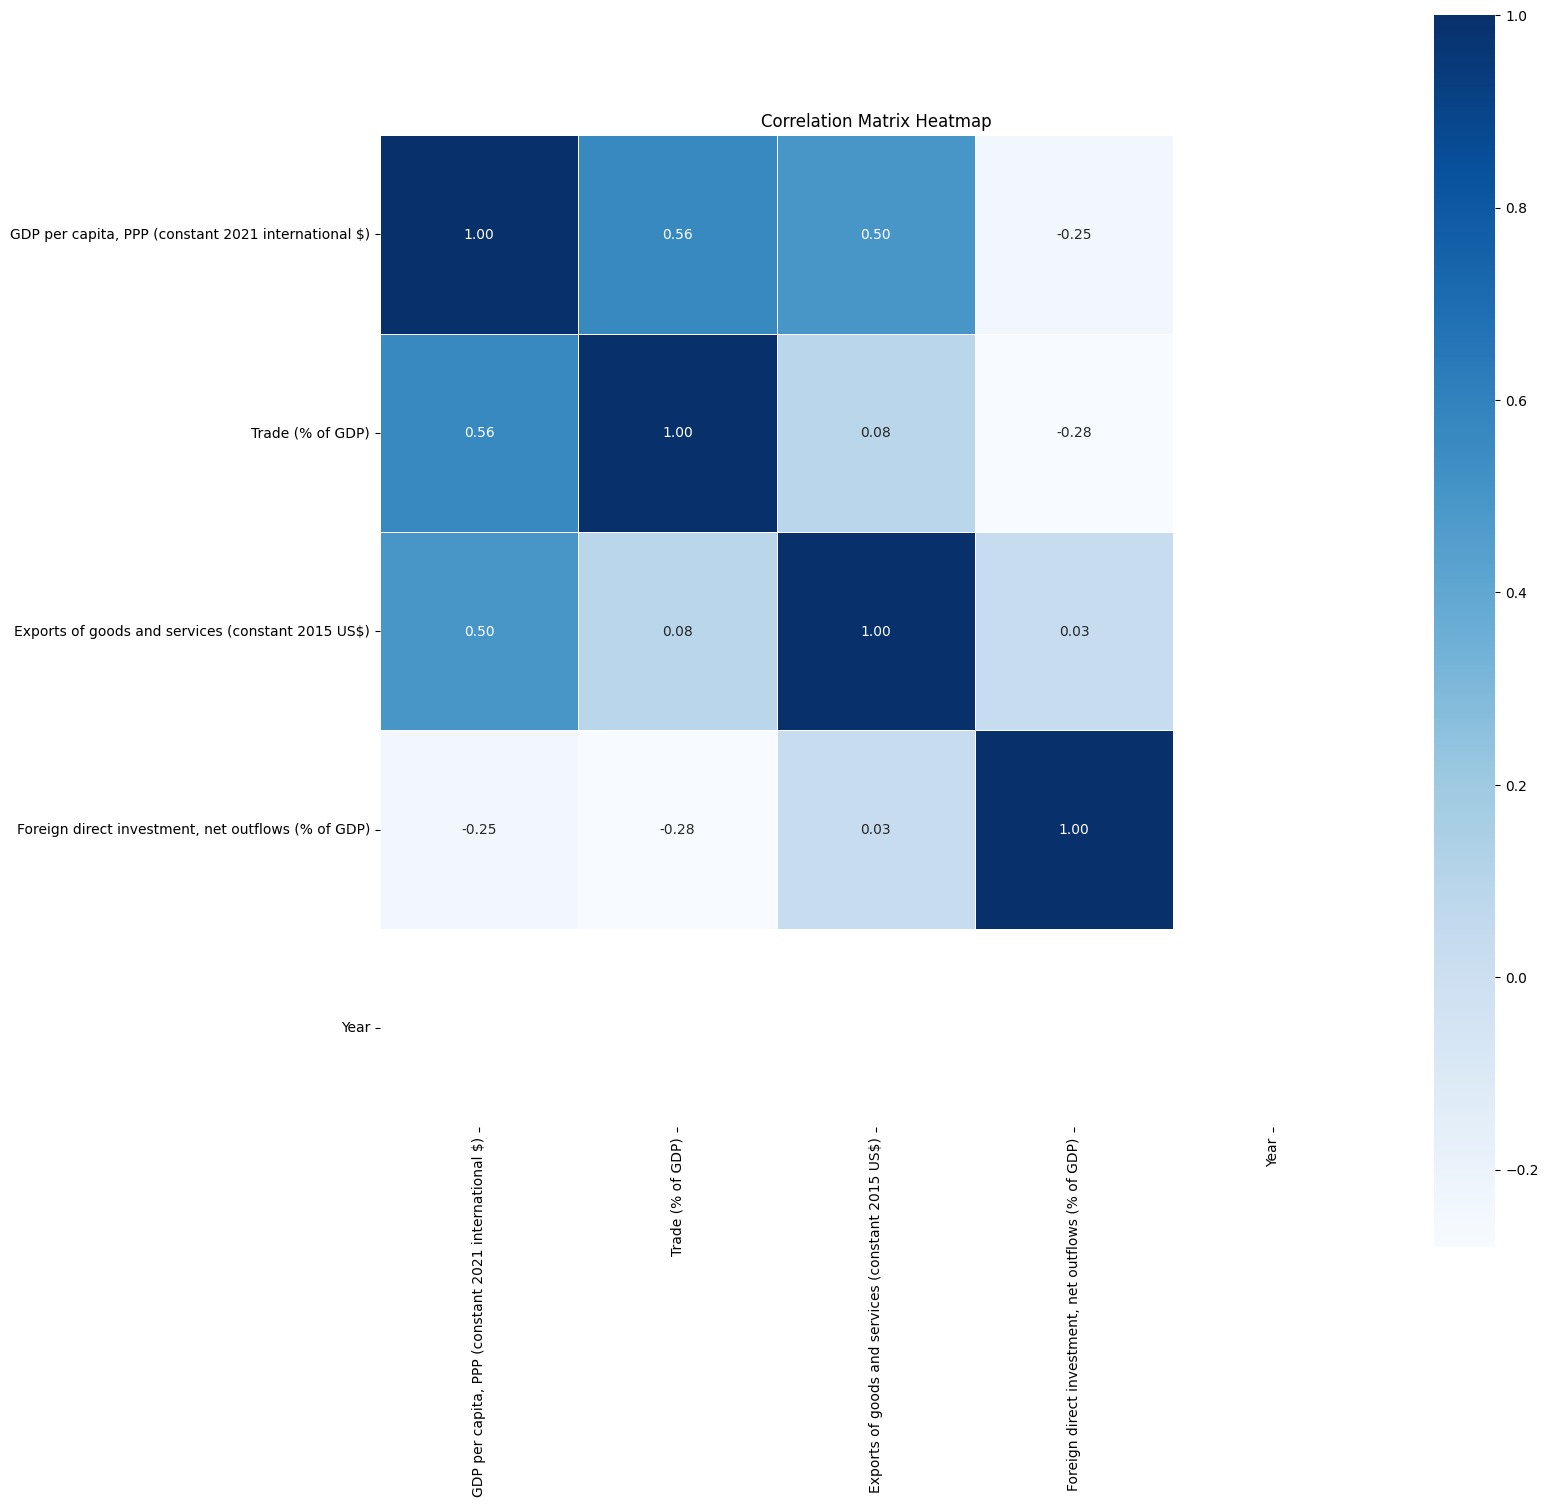

In [5]:
corr_matrix = df_numerik.corr()

sorted_correlation = corr_matrix["GDP per capita, PPP (constant 2021 international $)"].sort_values(ascending=False)

correlated_columns = sorted_correlation.index

subset_corr_matrix = corr_matrix.loc[correlated_columns, correlated_columns]

plt.figure(figsize=(16,16))

sns.heatmap(subset_corr_matrix, annot= True, cmap='Blues', linewidths=0.5, fmt=".2f", square= True)

plt.title("Correlation Matrix Heatmap")

plt.show()

In [6]:
gpkg_file_path = 'C:/Uner/Lomba/Nacoesta/gadm_410.gpkg' 
try:
    gdf_world = gpd.read_file(gpkg_file_path)
except FileNotFoundError:
    print(f"Error: File GeoPackage '{gpkg_file_path}' tidak ditemukan. Harap pastikan jalur sudah benar.")
    exit()
except Exception as e:
    print(f"Error saat memuat GeoPackage: {e}")
    exit()

In [7]:
print("\n--- 1.1. Subsetting Data ---")
required_cols_df = [
    'Entity',
    'Exports of goods and services (constant 2015 US$)',
    'Foreign direct investment, net outflows (% of GDP)',
    'GDP per capita, PPP (constant 2021 international $)',
    'Trade (% of GDP)'
]

# Pastikan semua kolom yang diperlukan ada di DataFrame Anda
missing_cols = [col for col in required_cols_df if col not in df.columns]
if missing_cols:
    print(f"Error: Kolom berikut tidak ditemukan di 'sembarang_baru.csv': {missing_cols}")
    print("Harap periksa nama kolom di file CSV Anda.")
    exit()

df_subset = df[required_cols_df].copy()
print(f"Data subset berhasil dibuat dengan {df_subset.shape[1]} kolom dan {df_subset.shape[0]} baris.")
print("Kolom yang dipilih:", df_subset.columns.tolist())
print("\n5 baris pertama data subset:")
print(df_subset.head())


--- 1.1. Subsetting Data ---
Data subset berhasil dibuat dengan 5 kolom dan 138 baris.
Kolom yang dipilih: ['Entity', 'Exports of goods and services (constant 2015 US$)', 'Foreign direct investment, net outflows (% of GDP)', 'GDP per capita, PPP (constant 2021 international $)', 'Trade (% of GDP)']

5 baris pertama data subset:
      Entity  Exports of goods and services (constant 2015 US$)  \
0    Albania                                         5369630266   
1    Algeria                                        35079226621   
2     Angola                                        18269753380   
3  Argentina                                        71194353193   
4    Armenia                                         6973017223   

   Foreign direct investment, net outflows (% of GDP)  \
0                                           1.007042    
1                                           0.037488    
2                                           0.039336    
3                                     

In [8]:
# --- 1.2.1. Identifikasi Kolom Nama Negara di GADM ---
# BERDASARKAN OUTPUT DARI BAGIAN 0, GANTI 'NAMA_KOLOM_NEGARA_GADM_YANG_BENAR'
# Contoh: Jika output gdf_world.columns.tolist() menunjukkan 'ADM0_EN', maka ganti dengan 'ADM0_EN'
# Jika output menunjukkan 'NAME_0', maka biarkan 'NAME_0'
gadm_country_col = 'NAME_0' # <--- UBAH INI JIKA PERLU!

if gadm_country_col not in gdf_world.columns:
    print(f"Error: Kolom nama negara '{gadm_country_col}' tidak ditemukan di GeoDataFrame GADM.")
    print(f"Kolom yang tersedia di GADM adalah: {gdf_world.columns.tolist()}")
    print("Harap perbarui variabel 'gadm_country_col' di script ini dengan nama kolom yang benar.")
    exit()
else:
    print(f"Menggunakan '{gadm_country_col}' sebagai kolom nama negara dari GADM.")



Menggunakan 'NAME_0' sebagai kolom nama negara dari GADM.


In [9]:
# --- 1.2.2. Standardisasi Nama Negara ---
# Ini adalah langkah KRITIS. Anda harus memastikan nama negara di df_subset ('Entity')
# cocok dengan nama negara di gdf_world (kolom yang Anda identifikasi sebagai gadm_country_col).
# Anda mungkin perlu MENAMBAH banyak pemetaan di sini.
print("Melakukan standardisasi nama negara untuk penggabungan...")
name_mapping = {
    'United States of America': 'United States',
    'Russian Federation': 'Russia',
    'Republic of Korea': 'South Korea', # Asumsi nama di GADM
    'Iran (Islamic Republic of)': 'Iran',
    'Libyan Arab Jamahiriya': 'Libya',
    'Democratic Republic of the Congo': 'Dem. Rep. Congo', # Atau 'Congo, Dem. Rep.'
    'Congo': 'Republic of the Congo', # Atau 'Congo (Republic)'
    'U.K. of Great Britain and Northern Ireland': 'United Kingdom',
    'Moldova, Republic of': 'Moldova',
    'Timor-Leste': 'Timor-Leste',
    'Bosnia & Herzegovina': 'Bosnia and Herzegovina',
    'Czech Republic': 'Czechia',
    'Gambia': 'Gambia, The',
    'Myanmar': 'Burma', # Jika GADM menggunakan Burma
    'Bahamas': 'The Bahamas',
    'Guinea-Bissau': 'Guinea-Bissau',
    'Slovakia': 'Slovakia', # Pastikan konsisten
    'Venezuela': 'Venezuela, RB', # Jika GADM menggunakan ini
    'Vietnam': 'Vietnam', # Pastikan konsisten
    'Bolivia': 'Bolivia (Plurinational State of)', # Contoh penyesuaian jika GADM menggunakan nama panjang
    # Tambahkan lebih banyak pemetaan jika ada ketidaksesuaian nama negara
    # Anda bisa membandingkan:
    # set(df_subset['Entity'].unique()) - set(gdf_world[gadm_country_col].unique())
    # set(gdf_world[gadm_country_col].unique()) - set(df_subset['Entity'].unique())
    # untuk menemukan nama yang tidak cocok.
}

df_subset['Entity_Standardized'] = df_subset['Entity'].replace(name_mapping)
print("Standardisasi nama negara selesai. Kolom 'Entity_Standardized' dibuat.")


Melakukan standardisasi nama negara untuk penggabungan...
Standardisasi nama negara selesai. Kolom 'Entity_Standardized' dibuat.


In [10]:
# --- 1.2.3. Penggabungan Data Geografis dan Tabular ---
print("Menggabungkan data geografis dan tabular berdasarkan nama negara...")
# Menggunakan 'inner' join agar hanya negara yang ada di kedua dataset yang disertakan
gdf_merged = gdf_world.merge(df_subset, left_on=gadm_country_col, right_on='Entity_Standardized', how='inner')

print(f"Jumlah negara setelah penggabungan: {len(gdf_merged)}.")
if len(gdf_merged) == 0:
    print("Peringatan: Tidak ada negara yang berhasil digabungkan! Periksa kembali pemetaan nama negara Anda.")
    exit()
print("\n5 baris pertama GeoDataFrame hasil penggabungan:")
print(gdf_merged.head())

Menggabungkan data geografis dan tabular berdasarkan nama negara...
Jumlah negara setelah penggabungan: 335223.

5 baris pertama GeoDataFrame hasil penggabungan:
   UID GID_0   NAME_0 VARNAME_0    GID_1 NAME_1 VARNAME_1 NL_NAME_1  ISO_1  \
0  349   ALB  Albania            ALB.1_1  Berat                      AL-01   
1  350   ALB  Albania            ALB.1_1  Berat                      AL-01   
2  351   ALB  Albania            ALB.1_1  Berat                      AL-01   
3  352   ALB  Albania            ALB.1_1  Berat                      AL-01   
4  353   ALB  Albania            ALB.1_1  Berat                      AL-01   

  HASC_1  ...  COUNTRY CONTINENT SUBCONT  \
0  AL.BE  ...  Albania    Europe           
1  AL.BE  ...  Albania    Europe           
2  AL.BE  ...  Albania    Europe           
3  AL.BE  ...  Albania    Europe           
4  AL.BE  ...  Albania    Europe           

                                            geometry   Entity  \
0  MULTIPOLYGON (((19.95771 40.72117, 1

In [11]:
# --- 1.2.4. Penanganan Missing Values pada Variabel Utama ---
# Variabel yang akan digunakan dalam regresi: Y_col dan X_cols.
Y_col = 'GDP per capita, PPP (constant 2021 international $)'
X_cols = [
    'Exports of goods and services (constant 2015 US$)',
    'Foreign direct investment, net outflows (% of GDP)',
    'Trade (% of GDP)'
]

# Pastikan variabel utama ada di GeoDataFrame yang digabungkan
for col in [Y_col] + X_cols:
    if col not in gdf_merged.columns:
        print(f"Error: Kolom '{col}' tidak ditemukan di GeoDataFrame setelah penggabungan.")
        print("Ini mungkin berarti kolom tersebut tidak ada di CSV Anda atau penggabungan gagal.")
        exit()

print(f"Mengecek missing values pada variabel '{Y_col}' dan {X_cols}...")
initial_rows_after_merge = len(gdf_merged)
gdf_merged.dropna(subset=[Y_col] + X_cols, inplace=True)
dropped_rows = initial_rows_after_merge - len(gdf_merged)
print(f"Dihapus {dropped_rows} baris karena memiliki missing values pada variabel kunci.")
print(f"Jumlah negara yang siap untuk analisis: {len(gdf_merged)}.")

if len(gdf_merged) < 2:
    print("Error: Tidak cukup data setelah penanganan missing values untuk analisis spasial.")
    print("Pertimbangkan metode penanganan missing values lain atau periksa data Anda.")
    exit()

# Konversi kolom numerik yang mungkin dibaca sebagai object menjadi numerik
# Ini penting untuk memastikan perhitungan statistik tidak error
for col in [Y_col] + X_cols:
    gdf_merged[col] = pd.to_numeric(gdf_merged[col], errors='coerce')
    # Setelah konversi, cek lagi jika ada NaN yang mungkin muncul dari 'coerce'
    if gdf_merged[col].isnull().any():
        print(f"Peringatan: Kolom '{col}' memiliki nilai non-numerik yang dikonversi menjadi NaN.")
        gdf_merged.dropna(subset=[col], inplace=True) # Hapus lagi baris dengan NaN baru
        print(f"Jumlah baris setelah penghapusan NaN tambahan di '{col}': {len(gdf_merged)}")


Mengecek missing values pada variabel 'GDP per capita, PPP (constant 2021 international $)' dan ['Exports of goods and services (constant 2015 US$)', 'Foreign direct investment, net outflows (% of GDP)', 'Trade (% of GDP)']...
Dihapus 0 baris karena memiliki missing values pada variabel kunci.
Jumlah negara yang siap untuk analisis: 335223.


In [12]:
# --- 1.3. EDA (Exploratory Data Analysis) ---
print("\n--- 1.3. EDA (Exploratory Data Analysis) ---")


--- 1.3. EDA (Exploratory Data Analysis) ---


In [13]:
# --- 1.3.1. Deskripsi Statistik Variabel Utama ---
print("\nDeskripsi Statistik Variabel Utama:")
print(gdf_merged[[Y_col] + X_cols].describe())


Deskripsi Statistik Variabel Utama:
       GDP per capita, PPP (constant 2021 international $)  \
count                                      335223.000000     
mean                                        26872.073534     
std                                         22445.643447     
min                                           829.387150     
25%                                          9457.104000     
50%                                         13334.294000     
75%                                         52924.610000     
max                                        137059.190000     

       Exports of goods and services (constant 2015 US$)  \
count                                       3.352230e+05   
mean                                        3.794488e+11   
std                                         4.259651e+11   
min                                         1.832354e+07   
25%                                         1.232839e+11   
50%                                         


Membuat Peta Choropleth untuk 'GDP per capita, PPP (constant 2021 international $)'...


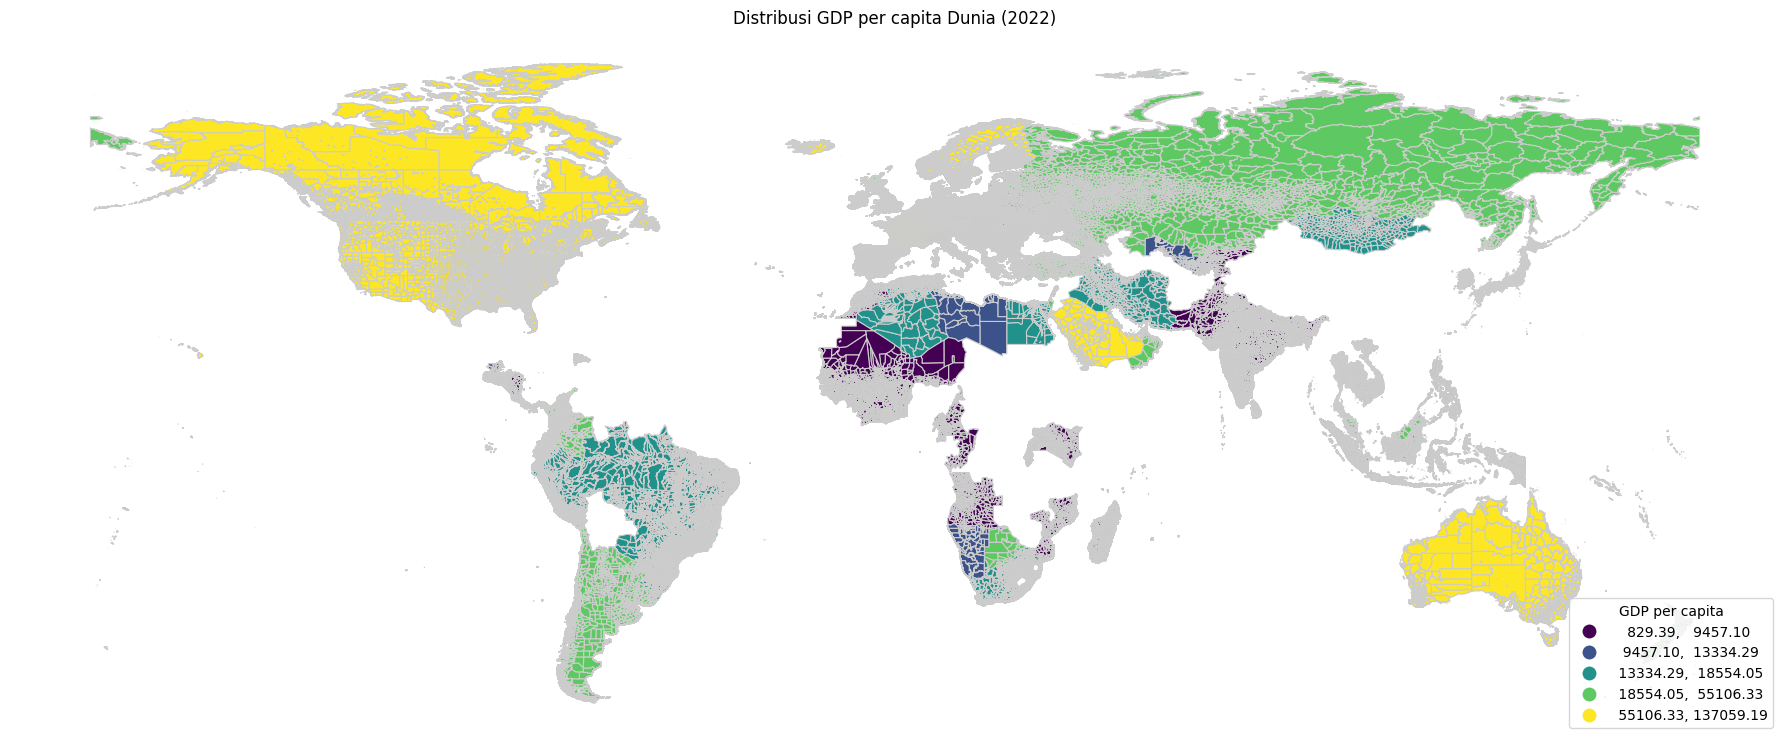

Peta Choropleth tersimpan sebagai 'eda_gdp_per_capita_map.png'


In [14]:
# --- 1.3.2. Visualisasi Peta Choropleth untuk Variabel Dependen (GDP per Kapita) ---
print(f"\nMembuat Peta Choropleth untuk '{Y_col}'...")
fig, ax = plt.subplots(1, 1, figsize=(18, 12))
gdf_merged.plot(column=Y_col,
                cmap='viridis', # Colormap yang menarik
                linewidth=0.8,
                ax=ax,
                edgecolor='0.8', # Warna batas antar negara
                legend=True,
                scheme='quantiles', # Metode klasifikasi data (misal: 'natural_breaks', 'equal_interval')
                legend_kwds={'loc': 'lower right', 'title': Y_col.replace(' (constant 2021 international $)', '').replace(', PPP', '')}) # Judul legenda
ax.set_title(f'Distribusi {Y_col.replace(", PPP (constant 2021 international $)", "")} Dunia (2022)')
ax.set_axis_off() # Menghilangkan sumbu x dan y
plt.tight_layout() # Menyesuaikan layout agar pas
plt.savefig('eda_gdp_per_capita_map.png', dpi=300) # Simpan peta
plt.show()
print(f"Peta Choropleth tersimpan sebagai 'eda_gdp_per_capita_map.png'")

In [ ]:
# --- 1.3.3. Pembentukan Matriks Bobot Spasial (Spatial Weights Matrix) ---
# Matriks bobot spasial mendefinisikan 'ketetanggaan' antar unit geografis.
# 'Queen' contiguity berarti dua negara bertetangga jika mereka berbagi batas atau sudut.
print("\nMembangun matriks bobot spasial (Queen Contiguity)...")
# Pastikan CRS (Coordinate Reference System) GeoDataFrame adalah proyeksi yang sesuai
# jika Anda berencana menggunakan bobot berbasis jarak. Untuk contiguity, CRS geografis (Lat/Lon) umumnya tidak masalah.
# Namun, jika ada masalah, pertimbangkan untuk memproyeksikan: gdf_merged = gdf_merged.to_crs("EPSG:3857")

w = weights.Queen.from_dataframe(gdf_merged)
w.set_op_weights('b') # Baris distandardisasi (row-standardized): jumlah bobot tetangga setiap negara adalah 1
print(f"Jumlah koneksi spasial unik (komponen): {w.n_components}")
print(f"Rata-rata jumlah tetangga per negara: {w.mean_neighbors:.2f}")


Membangun matriks bobot spasial (Queen Contiguity)...


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_31620\3470669377.py:9: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = weights.Queen.from_dataframe(gdf_merged)


In [ ]:
# --- 1.3.4. Uji Autokorelasi Spasial Global (Moran's I) untuk Variabel Dependen ---
# Mengukur apakah ada pola spasial (kluster) pada variabel GDP per Kapita.
print(f"\nMelakukan Uji Moran's I Global untuk '{Y_col}'...")
# Pastikan Y adalah array numpy
Y_values = gdf_merged[Y_col].values


In [ ]:
moran_gdp = esda.Moran(Y_values, w)
print(f"Hasil Uji Moran's I Global untuk '{Y_col}':")
print(f"  Moran's I (I): {moran_gdp.I:.4f}")
print(f"  Expected I (EI): {moran_gdp.EI:.4f}")
print(f"  Variance (V_sim): {moran_gdp.V_sim:.4f}")
print(f"  Z-score (z_sim): {moran_gdp.z_sim:.4f}")
print(f"  P-value (p_sim, menggunakan simulasi): {moran_gdp.p_sim:.4f}")

if moran_gdp.p_sim < 0.05:
    print(f"  -> Kesimpulan: Ada autokorelasi spasial positif yang signifikan pada '{Y_col}'.")
    print("     Ini menunjukkan bahwa negara dengan PDB per Kapita tinggi cenderung bertetangga dengan negara PDB tinggi,")
    print("     dan negara PDB rendah cenderung bertetangga dengan negara PDB rendah (kluster).")
    # Plot Moran Scatter Plot jika signifikan
    print("Membuat Moran Scatter Plot untuk visualisasi autokorelasi spasial...")
    fig, ax = plot_moran_scatterplot(moran_gdp, zstandard=True, aspect_equal=True)
    ax.set_xlabel(f"{Y_col} (Standardized)")
    ax.set_ylabel(f"Spatial Lag of {Y_col} (Standardized)")
    ax.set_title(f"Moran Scatter Plot untuk {Y_col}")
    plt.tight_layout()
    plt.savefig('eda_moran_scatter_plot_gdp.png', dpi=300)
    plt.show()
    print("Moran Scatter Plot tersimpan sebagai 'eda_moran_scatter_plot_gdp.png'")
else:
    print(f"  -> Kesimpulan: Tidak ada autokorelasi spasial signifikan pada '{Y_col}'.")


print("\n--- Bagian 1 Selesai. Data telah disiapkan dan dieksplorasi. ---")
print("GeoDataFrame 'gdf_merged' kini siap untuk pemodelan regresi spasial.")

### Pemodelan Regresi

In [ ]:
# --- 2.1. Pemodelan Regresi ---

# --- 2.1.1. Model OLS (Ordinary Least Squares) ---
print("\n### 2.1.1. Model OLS (Ordinary Least Squares) ###")
try:
    ols_model = spreg.OLS(Y, X, w=w, name_y=Y_col, name_x=X_names)
    print(ols_model.summary)
except Exception as e:
    print(f"Error saat menjalankan model OLS: {e}")
    ols_model = None # Set to None if error occurs

In [ ]:
# --- 2.1.2. Model SAR (Spatial Autoregressive Model) ---
print("\n### 2.1.2. Model SAR (Spatial Autoregressive Model) ###")
try:
    sar_model = spreg.ML_Lag(Y, X, w=w, name_y=Y_col, name_x=X_names)
    print(sar_model.summary)
    print(f"Koefisien Rho (Spatial Lag, ρ): {sar_model.rho[0]:.4f} (p-value: {sar_model.rho[1]:.4f})")
except Exception as e:
    print(f"Error saat menjalankan model SAR: {e}")
    sar_model = None

In [ ]:
# --- 2.1.3. Model SEM (Spatial Error Model) ---
print("\n### 2.1.3. Model SEM (Spatial Error Model) ###")
try:
    sem_model = spreg.ML_Error(Y, X, w=w, name_y=Y_col, name_x=X_names)
    print(sem_model.summary)
    print(f"Koefisien Lambda (Spatial Error, λ): {sem_model.lmbda[0]:.4f} (p-value: {sem_model.lmbda[1]:.4f})")
except Exception as e:
    print(f"Error saat menjalankan model SEM: {e}")
    sem_model = None

In [ ]:
# --- 2.2.1. Evaluasi OLS & Visualisasi Residual ---
if ols_model:
    print("\n--- 2.2.1. Evaluasi OLS & Visualisasi Residual ---")
    moran_res_ols = esda.Moran(ols_model.residuals, w)
    print("\nHasil Uji Moran's I pada Residual OLS:")
    print(f"  Moran's I (I): {moran_res_ols.I:.4f}")
    print(f"  P-value (simulasi): {moran_res_ols.p_sim:.4f}")
    if moran_res_ols.p_sim < 0.05:
        print("  -> Kesimpulan: Autokorelasi spasial signifikan pada residual OLS. Ini menunjukkan OLS gagal menangkap semua dependensi spasial.")
    else:
        print("  -> Kesimpulan: Tidak ada autokorelasi spasial signifikan pada residual OLS. OLS cukup baik menangkap pola spasial (namun perlu dibandingkan dengan model spasial).")

    gdf_merged['OLS_Residuals'] = ols_model.residuals.flatten()

    print("Membuat Peta Residual OLS...")
    fig, ax = plt.subplots(1, 1, figsize=(18, 12))
    gdf_merged.plot(column='OLS_Residuals',
                    cmap='RdBu',
                    linewidth=0.8,
                    ax=ax,
                    edgecolor='0.8',
                    legend=True,
                    scheme='quantiles',
                    legend_kwds={'loc': 'lower right', 'title': 'Residual OLS'})
    ax.set_title('Peta Residual Model OLS (GDP per Kapita)')
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('visual_ols_residuals_map.png', dpi=300)
    plt.show()
    print("Peta Residual OLS tersimpan sebagai 'visual_ols_residuals_map.png'")

    if moran_res_ols.p_sim < 0.05:
        print("Membuat Peta LISA untuk Residual OLS (Hot/Cold Spots)...")
        lisa_ols_residuals = esda.Moran_Local(ols_model.residuals.flatten(), w)
        fig, ax = plot_local_autocorrelation(lisa_ols_residuals, gdf_merged, 'OLS_Residuals',
                                             quads=True,
                                             figsize=(18, 12))
        ax.set_title('Peta LISA Residual OLS (Hot/Cold Spots)')
        ax.set_axis_off()
        plt.tight_layout()
        plt.savefig('visual_lisa_ols_residuals.png', dpi=300)
        plt.show()
        print("Peta LISA Residual OLS tersimpan sebagai 'visual_lisa_ols_residuals.png'")


In [ ]:
# --- 2.2.2. & 2.2.3. Visualisasi Dampak Spasial Model SAR/SEM (Opsional, Interpretatif) ---
# Untuk infografis, visualisasi residual atau perbandingan AIC/BIC lebih utama.
# Penjelasan konsep di bagian 2.3 akan lebih efektif daripada peta yang kompleks di sini.
if sar_model:
    print("\n--- 2.2.2. Visualisasi Konseptual Dampak SAR ---")
    print("SAR mempertimbangkan bagaimana PDB per kapita suatu negara dipengaruhi oleh PDB tetangganya.")
    print("Visualisasi GDP per Kapita dari EDA sebelumnya juga relevan di sini untuk menunjukkan kluster.")
    # Jika perlu visualisasi SAR, Anda bisa membuat peta nilai prediksi SAR atau perbedaannya dengan OLS.
    # Contoh: gdf_merged['SAR_Predicted'] = sar_model.predy.flatten()
    #         gdf_merged.plot(column='SAR_Predicted', ...)

    if sem_model:
    print("\n--- 2.2.3. Visualisasi Konseptual Dampak SEM ---")
    print("SEM mengatasi pola spasial yang mungkin ada pada error (variabel tidak teramati).")
    try:
        moran_res_sem = esda.Moran(sem_model.residuals, w)
        print("\nHasil Uji Moran's I pada Residual SEM:")
        print(f"  Moran's I (I): {moran_res_sem.I:.4f}")
        print(f"  P-value (simulasi): {moran_res_sem.p_sim:.4f}")
        if moran_res_sem.p_sim < 0.05:
            print("  -> Peringatan: Autokorelasi spasial signifikan pada residual SEM. Model SEM mungkin tidak sepenuhnya mengatasi dependensi spasial.")
        else:
            print("  -> Kesimpulan: Tidak ada autokorelasi spasial signifikan pada residual SEM. Model SEM berhasil mengatasi dependensi spasial pada error.")
    except Exception as e:
        print(f"Tidak dapat menghitung Moran I untuk residual SEM: {e}")


In [ ]:
# --- 2.3. Perbandingan Model ---
print("\n--- 2.3. Perbandingan Model ---")

model_results = {}

if ols_model:
    model_results['OLS'] = {
        'Adj. R-squared': ols_model.r2a[0],
        'Moran I Residuals': moran_res_ols.I,
        'Moran I Residuals P-value': moran_res_ols.p_sim,
        'AIC': ols_model.aic,
        'BIC': ols_model.bic,
        'Log Likelihood': ols_model.llik
    }
    print(f"\n--- Ringkasan OLS ---")
    for metric, value in model_results['OLS'].items():
        print(f"  {metric}: {value:.4f}" if isinstance(value, float) else f"  {metric}: {value}")


if sar_model:
    model_results['SAR'] = {
        'Adj. R-squared': sar_model.r2a[0],
        'Spatial Lag (Rho)': sar_model.rho[0],
        'Spatial Lag (Rho) P-value': sar_model.rho[1],
        'AIC': sar_model.aic,
        'BIC': sar_model.bic,
        'Log Likelihood': sar_model.llik
    }
    print(f"\n--- Ringkasan SAR ---")
    for metric, value in model_results['SAR'].items():
        print(f"  {metric}: {value:.4f}" if isinstance(value, float) else f"  {metric}: {value}")


if sem_model:
    model_results['SEM'] = {
        'Adj. R-squared': sem_model.r2a[0],
        'Spatial Error (Lambda)': sem_model.lmbda[0],
        'Spatial Error (Lambda) P-value': sem_model.lmbda[1],
        'AIC': sem_model.aic,
        'BIC': sem_model.bic,
        'Log Likelihood': sem_model.llik
    }
    print(f"\n--- Ringkasan SEM ---")
    for metric, value in model_results['SEM'].items():
        print(f"  {metric}: {value:.4f}" if isinstance(value, float) else f"  {metric}: {value}")


In [ ]:
# Visualisasi Perbandingan Metrik (Bar Chart)
print("\n--- Visualisasi Perbandingan Metrik Model ---")
metrics_to_compare = ['Adj. R-squared', 'AIC', 'BIC']
model_names = []
r2_values = []
aic_values = []
bic_values = []

for model_name, metrics in model_results.items():
    model_names.append(model_name)
    r2_values.append(metrics.get('Adj. R-squared', np.nan))
    aic_values.append(metrics.get('AIC', np.nan))
    bic_values.append(metrics.get('BIC', np.nan))

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Adj. R-squared': r2_values,
    'AIC': aic_values,
    'BIC': bic_values
})

In [ ]:
# Plot Adjusted R-squared
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(x='Model', y='Adj. R-squared', kind='bar', ax=ax, legend=False)
ax.set_title('Perbandingan Adjusted R-squared Antar Model')
ax.set_ylabel('Adjusted R-squared')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('comparison_adj_r2.png', dpi=300)
plt.show()
print("Grafik perbandingan Adjusted R-squared tersimpan sebagai 'comparison_adj_r2.png'")


In [ ]:
# Plot AIC
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(x='Model', y='AIC', kind='bar', ax=ax, legend=False, color='orange')
ax.set_title('Perbandingan AIC Antar Model (Lebih Kecil Lebih Baik)')
ax.set_ylabel('AIC')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('comparison_aic.png', dpi=300)
plt.show()
print("Grafik perbandingan AIC tersimpan sebagai 'comparison_aic.png'")


In [ ]:
# Plot BIC
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(x='Model', y='BIC', kind='bar', ax=ax, legend=False, color='green')
ax.set_title('Perbandingan BIC Antar Model (Lebih Kecil Lebih Baik)')
ax.set_ylabel('BIC')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('comparison_bic.png', dpi=300)
plt.show()
print("Grafik perbandingan BIC tersimpan sebagai 'comparison_bic.png'")


In [ ]:
print("\n--- Kesimpulan dan Rekomendasi Model Terbaik ---")
if model_results:
    best_model_name = None
    min_aic = float('inf')

    for model_name, metrics in model_results.items():
        if 'AIC' in metrics and metrics['AIC'] < min_aic:
            min_aic = metrics['AIC']
            best_model_name = model_name

    print(f"\nBerdasarkan kriteria AIC (Akaike Information Criterion, nilai terkecil lebih baik), model terbaik adalah: {best_model_name}")

    if 'ols_model' in locals() and 'moran_res_ols' in locals() and moran_res_ols.p_sim < 0.05:
        print("\n**Catatan Penting untuk Infografis Anda:**")
        print("Meskipun model OLS mungkin memberikan gambaran awal, **autokorelasi spasial yang signifikan terdeteksi pada residual OLS**.")
        print("Ini berarti model OLS tidak sepenuhnya menangkap pola spasial dalam data, dan asumsi independensi error tidak terpenuhi.")
        print("Oleh karena itu, **model spasial (SAR atau SEM) secara teori lebih tepat dan efisien** untuk data ini.")
        print("   - **Pilih model SAR** jika Anda percaya ada efek 'spillover' dari variabel dependen (GDP per Kapita tetangga).")
        print("   - **Pilih model SEM** jika Anda percaya ada pola spasial pada error yang tidak dijelaskan oleh variabel independen.")
        print(f"   - Bandingkan {best_model_name} dengan OLS terutama pada nilai AIC/BIC dan Adjusted R-squared.")
        print("     Model dengan AIC/BIC yang lebih rendah dan Adjusted R-squared yang lebih tinggi (jika peningkatannya substansial) adalah kandidat terbaik.")
    else:
        print("\n**Catatan Penting untuk Infografis Anda:**")
        print("Tidak ada autokorelasi spasial signifikan terdeteksi pada residual OLS.")
        print("Ini menunjukkan bahwa model OLS mungkin sudah memadai.")
        print("Namun, tetap pertimbangkan AIC/BIC dan Adjusted R-squared dari model SAR dan SEM untuk melihat apakah mereka memberikan penjelasan yang lebih baik.")
else:
    print("Tidak ada model yang berhasil dijalankan atau dievaluasi.")

print("\n--- Proses Analisis Spasial Lengkap Selesai ---")